## **Are You Actually Gonna Work for Us Someday? A Data-Driven  Investigation into Penn Band’s Controversial March Madness Chant**

<img src="coverImage.png" width="800">

On March 19, 2026, University of Pennsylvania fell 105–70 to University of Illinois Urbana-Champaign in the opening round of the NCAA Tournament, ending what had otherwise been one of the most celebrated seasons in recent Penn basketball history. The Quakers had reached March Madness for the first time since 2018, reigniting excitement across campus and drawing national attention to a program that had long struggled to reestablish itself on the national stage. Within the Penn community, much of the postgame discussion initially centered around basketball itself: the absence of Penn’s leading scorer Ethan Roberts, concerns surrounding junior forward TJ Powers’ illness leading into the game, and the broader accomplishment of an Ivy League team returning to the tournament after years of inconsistency. But by the end of the night, the game itself had become secondary.

As the final minutes ticked down and Penn’s win became impossible, members of the Penn Band began chanting from the sidelines:

## ***“That’s alright, that’s okay, you’re gonna work for us someday.”***

The moment was captured on video and rapidly spread across social media platforms, transforming an otherwise ordinary March Madness blowout into a national debate about elitism, prestige, and the meaning of higher education in America. 

A repost of the clip by Yahoo Sports on X accumulated more than 4.2 million views within days: thousands of comments condemned the chant as arrogant, classist, and emblematic of Ivy League entitlement. Critics pointed out the irony of Penn students directing the chant toward a university widely recognized for its academic and professional strength. Even members of Penn’s own academic community publicly distanced themselves from the chant, with several professors and alumni expressing embarrassment online over the national perception it created.

<img src="commentResponses.png" width="800">

In response to the backlash, the Penn Band’s 2026 Executive Board released a formal statement on Instagram apologizing to students, faculty, and alumni at UIUC:

## ***“We’d like to specifically apologize to the University of Illinois’s players, faculty, students, and alumni– as representatives of a fellow collegiate institution, we recognize and respect the many contributions the University of Illinois has made to its community and society at large. We believe that individuals are not defined by institutional membership, and we recognize that the implications of our chant were misaligned with that belief.”***

The statement attempted to close the controversy, yet the discourse surrounding the chant revealed something deeper than a moment of poor sportsmanship. Beneath the outrage existed a quieter, but persistent, counterargument. Across Reddit threads, anonymous campus forums like Sidechat, and comment sections discussing the incident, some defended the chant. Supporters pointed to Penn’s status as an Ivy League institution, Wharton’s dominance in finance and consulting recruitment, and the long-standing cultural association between Ivy League degrees and professional power. Others argued that chants like these have existed for decades within Ivy League athletics and reflected a broader stereotype rather than a literal claim of superiority.

The controversy therefore raises a larger and more uncomfortable question:

*How much does institutional prestige actually translate into measurable post-graduate advantage?*

More specifically, does attending an Ivy League university like Penn meaningfully provide stronger long-term career outcomes than attending a highly-ranked public institution like University of Illinois Urbana-Champaign? And if so, in what ways? Is prestige reflected primarily through salary, elite employment pipelines, and social capital, or are factors like student happiness, debt burden, career satisfaction, and return on investment equally important indicators of success?

Rather than treating the chant as simply offensive or justified, our project uses it as a starting point for a broader investigation into the real-world value of elite higher education. By combining quantitative labor-market data with qualitative sentiment analysis, we aim to move beyond stereotypes and examine whether the assumptions embedded within the chant actually hold up under empirical scrutiny.


## Comparing Prestige and Perception: A Data-Driven Look at UPenn and UIUC Overall

When analyzing both schools, we looked into two aspects (quantitative and qualitative) to determine overall post-graduate advantage. On the quantitative side, it strictly involved analyzing financial measures like Median Earnings, ROI, Median Debt, Debt-to-Income Ratio, Demographics, Income Mobility, and Location. On the qualitative side, it included a sentiment analysis that numerically ranked online impressions of respective schools. 

After analyzing both sides of the data, it revealed that the conversation was much more nuanced than which school had a better outcome. Penn appeared to have a stronger financial return post graduation at the expense of a high pressure undergraduate experience, while UIUC appeared to have a more positive undergraduate experience with a lower long-term financial return. 


## The Numbers Behind the Degree: Earnings, Debt, ROI, and Economic Outcomes

Penn scored higher than UIUC across several financial aspects. Penn graduates reported higher median earnings at both the 6-year and 10-year mark. Penn graduates earned substantially more than UIUC graduates. The Penn median salary at 6 years was $85,900 and at 10 years $105,500. For UIUC, it was $51,000 at 6 years and $66,100 at 10 years. 

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [43]:
college_df = pd.read_csv('../data/raw/Overall_Data/overall.csv')

In [27]:
cleaned_df = college_df.rename(columns={
    "Median Earnings (6 yrs post-entry)": "earnings_6yr",
    "Median Earnings (10 yrs post-entry)": "earnings_10yr"
})

In [28]:
earnings_compare = cleaned_df[
    cleaned_df["School"].isin([
        "University of Pennsylvania",
        "University of Illinois Urbana-Champaign"
    ])
][["School", "earnings_6yr", "earnings_10yr"]]

earnings_compare

,School,earnings_6yr,earnings_10yr
4,University of Pennsylvania,$85900,$105500
9,University of Illinois Urbana-Champaign,$51000,$66100


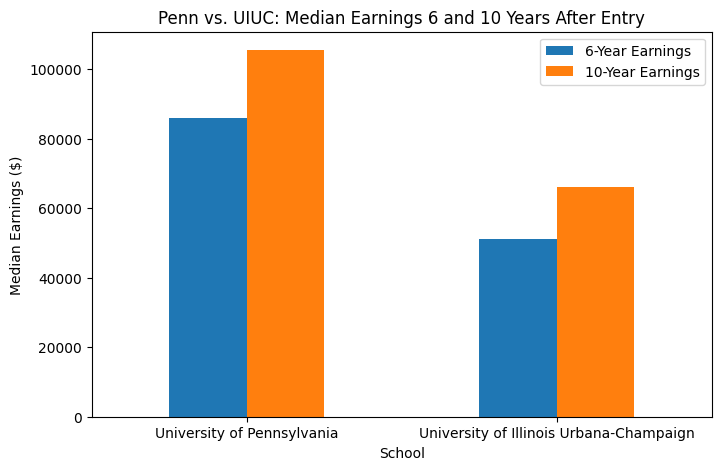

In [29]:
earnings_compare["earnings_6yr"] = earnings_compare["earnings_6yr"].str.replace("$", "").astype(int)
earnings_compare["earnings_10yr"] = earnings_compare["earnings_10yr"].str.replace("$", "").astype(int)

earnings_compare.set_index("School").plot(kind="bar", figsize=(8,5))

plt.title("Penn vs. UIUC: Median Earnings 6 and 10 Years After Entry")
plt.xlabel("School")
plt.ylabel("Median Earnings ($)")
plt.xticks(rotation=0)
plt.legend(["6-Year Earnings", "10-Year Earnings"])

plt.show()

Comparing each school’s average annual net cost with students’ median earnings after graduation, Penn had nearly double UIUC’s return on investment both at six years and 10 years. This went against the preconceived notion that public universities and state schools offer a better financial offer long-term. Penn’s higher post-graduation earnings offset the school’s higher tuition dramatically. Although Penn appears to be more expensive, the long-term benefits regarding income nearly double that of UIUC. 

In [36]:
compare = cleaned_df[
    cleaned_df["School"].isin([
        "University of Pennsylvania",
        "University of Illinois Urbana-Champaign"
    ])
][["School", "earnings_6yr", "earnings_10yr", "Median Debt at Graduation", "Avg Annual Cost (Net Price)"]]

compare["earnings_6yr"] = compare["earnings_6yr"].str.replace("$", "").astype(int)
compare["earnings_10yr"] = compare["earnings_10yr"].str.replace("$", "").astype(int)

compare["cost"] = compare["Avg Annual Cost (Net Price)"].str.replace("$", "").str.replace(",", "").astype(int) * 4

compare["roi_6yr"] = ((compare["earnings_6yr"] * 6 - compare["cost"]) / compare["cost"]) * 100
compare["roi_10yr"] = ((compare["earnings_10yr"] * 10 - compare["cost"]) / compare["cost"]) * 100

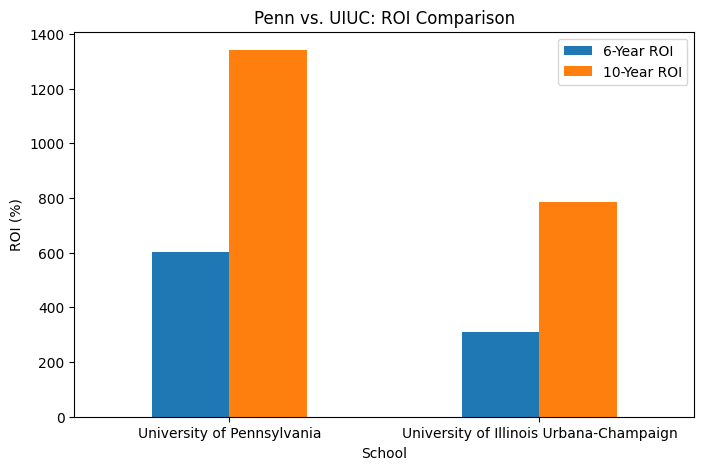

In [37]:
compare.set_index("School")[["roi_6yr", "roi_10yr"]].plot(kind="bar", figsize=(8,5))

plt.title("Penn vs. UIUC: ROI Comparison")
plt.ylabel("ROI (%)")
plt.xlabel("School")
plt.xticks(rotation=0)
plt.legend(["6-Year ROI", "10-Year ROI"])

plt.show()

However, ROI does not consider student-debt. Based on a compiled data set from government records, it revealed that Penn and UIUC students have similar debt levels at graduation. UIUC students have a median debt of $19,300 while Upenn students have a median debt of $18,300. UIUC has a slightly higher median debt, but with the difference only being about 5%. Although Ivy League schools are expected to leave students with considerable debt in comparison to a more practical options like state schools, this data conflicts with this expectation, indicating that UIUC students leave with slightly higher median debt. 

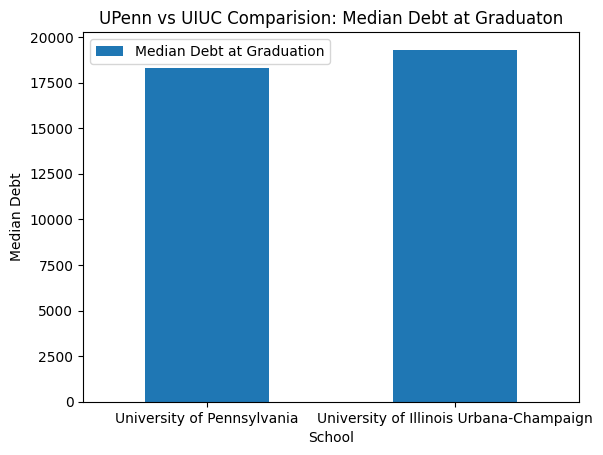

In [39]:
compare["Median Debt at Graduation"] = compare["Median Debt at Graduation"].str.replace("$", "").str.replace(",", "").astype(int)

compare.set_index("School")[["Median Debt at Graduation"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Median Debt at Graduaton")
plt.ylabel("Median Debt")
plt.xticks(rotation=0)
plt.show()

Even with similar debt levels, as Penn students earn more post-grad, Penn’s debt-to-income ratio (debt compared to relative income post graduation) is much lower. Penn’s debt-to-income ratio is at 21.3% compared to UIUC’s 37.8%. The data indicates that UIUC graduates carry a bigger financial burden post graduation even with similar debt levels. It seems that Penn students are left in a more favorable financial position at graduation.

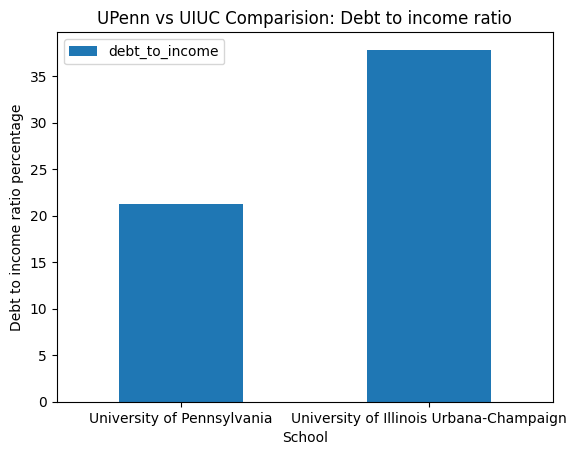

In [42]:
compare["debt_to_income"] = (compare["Median Debt at Graduation"] / compare["earnings_6yr"]) * 100

compare.set_index("School")[["debt_to_income"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Debt to income ratio")
plt.ylabel("Debt to income ratio percentage")
plt.xticks(rotation=0)
plt.show()

Based on this data alone, Penn seems to provide a much stronger financial outcome. However, the demographic and mobility data convolutes this claim. 

Although Penn students produce higher-earning graduates, the institution also enrolls an already wealthier student demographic. Based on the New York Times mobility index report card data gathered from tax records, Penn students come from wealthier households in comparison to UIUC students. The median family income of Penn students is $195,500 and for UIUC, $109,000. This is an important metric to consider, highlighting Penn students’ pre-existing advantages of coming from a higher income background. 

In [44]:
mobility_df = pd.read_csv('../data/raw/Overall_Data/upenn_mobility_clean.csv')

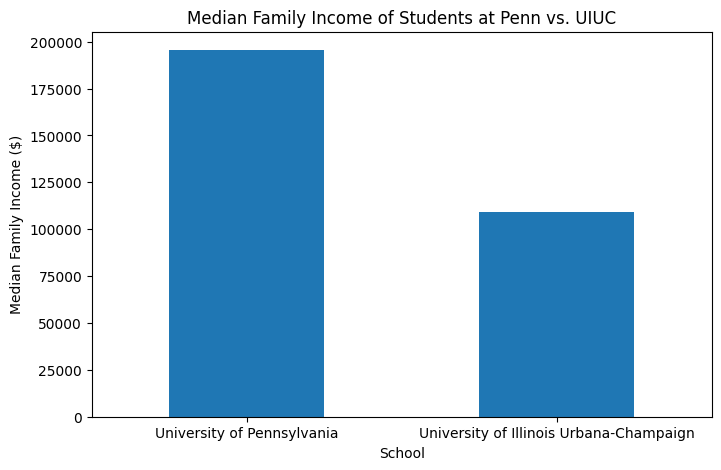

In [45]:
mobility_df.plot(
    x="school",
    y="median_family_income",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Median Family Income of Students at Penn vs. UIUC")
plt.xlabel("School")
plt.ylabel("Median Family Income ($)")
plt.xticks(rotation=0)
plt.show()

Penn also enrolls a higher group of students from the top 1%, while UIUC enrolls students largely from the bottom 20%. Penn graduates’ salaries can also be a reflection of pre-existing socioeconomic advantages that include things like networks, family wealth, and accessibility to elite career fields. 

UIUC seems to be stronger than Penn in the financial component of broader economic mobility. The data indicates that UIUC has a higher proportion of students moving up two or more income quintiles, suggesting that the school may serve as a stronger force for economic mobility across income groups instead of a concentrated group of high-income students. However, it is important to note that Penn does have a higher percentage of economic mobility in terms of moving the specific demographic of low-income students to the highest income threshold, but less of the overall student body. 


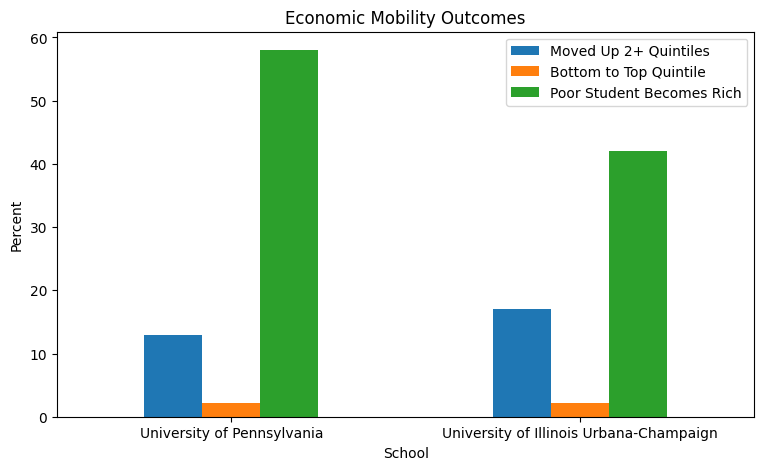

In [46]:
mobility_metrics = mobility_df.set_index("school")[[
    "pct_moved_up_2plus_quintiles",
    "pct_bottom_to_top_quintile",
    "pct_poor_student_becomes_rich"
]]

mobility_metrics.plot(kind="bar", figsize=(9,5))

plt.title("Economic Mobility Outcomes")
plt.xlabel("School")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.legend([
    "Moved Up 2+ Quintiles",
    "Bottom to Top Quintile",
    "Poor Student Becomes Rich"
])
plt.show()

Another interesting observation we came across was that the location of Penn graduates could either inflate or deflate their salaries’ value. Median income levels of Penn graduates are significantly higher than UIUC as analyzed above, but it is important to also consider the context of where Penn and UIUC graduates live post-graduation. 


Based on released Penn alumni data, it was posted that Penn alumni are concentrated in major cities like New York City, Philadelphia, and Boston. 


In [47]:
cities_df = pd.read_csv('../data/raw/Overall_Data/upenn_alumni_cities.csv')

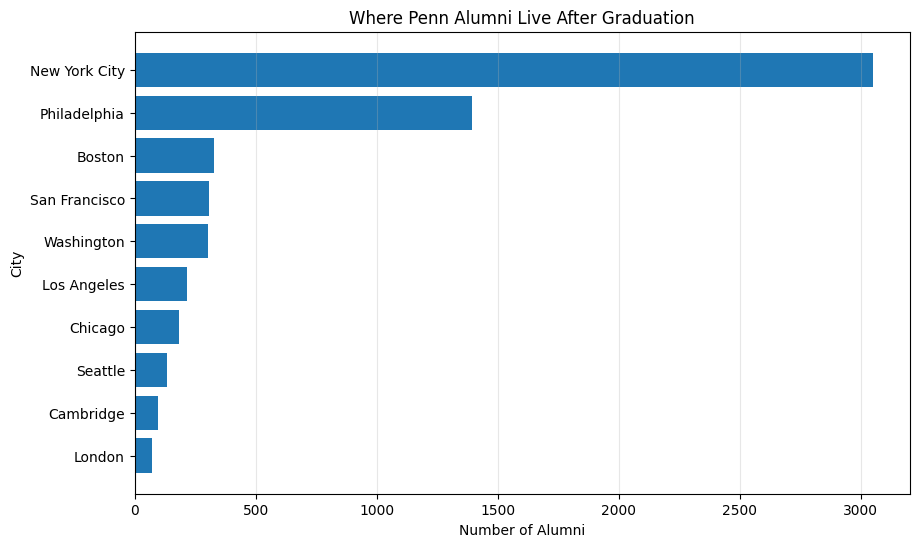

In [48]:
penn_df = cities_df.query('school == "University of Pennsylvania"')

penn_df = penn_df.sort_values("alumni_count")

plt.figure(figsize=(10,6))

plt.barh(
    penn_df["city"],
    penn_df["alumni_count"]
)

plt.xlabel("Number of Alumni")
plt.ylabel("City")

plt.title("Where Penn Alumni Live After Graduation")

plt.grid(axis="x", alpha=0.3)

plt.show()

Based on released UIUC alumni data, it was posted that UIUC alumni are majorly concentrated in the Illinois area with less variation in other cities and states like Penn. 

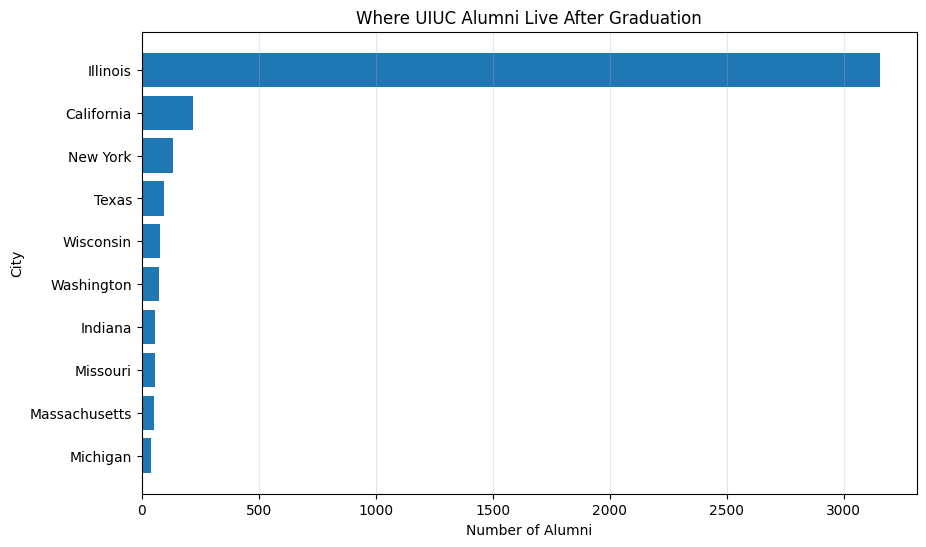

In [49]:
uiuc_df = cities_df.query('school == "University of Illinois Urbana-Champaign"')

uiuc_df = uiuc_df.sort_values("alumni_count")

plt.figure(figsize=(10,6))

plt.barh(
    uiuc_df["city"],
    uiuc_df["alumni_count"]
)

plt.xlabel("Number of Alumni")
plt.ylabel("City")

plt.title("Where UIUC Alumni Live After Graduation")

plt.grid(axis="x", alpha=0.3)

plt.show()

The data revealed that Penn grads are more concentrated in major cities that have higher costs of living than UIUC grads who live mostly in Chicago and the Midwestern area. The higher salaries of Penn students could be potentially deflated by the city which they live in, as the city involves more expenses. Penn graduates do have a salary advantage, but it is not a whole advantage considering where they live. 

As for the quantitative section, it revealed that the conversation is much more nuanced than which school has a better financial outcome. Although Penn seemed to provide stronger financial outcomes overall, UIUC was a stronger force for broader income mobility across socioeconomic groups. If success means a higher salary, Penn would lead UIUC with stronger ROI metrics and a lower debt-to-income ratio. However, a majority of Penn graduates are concentrated in major cities where the cost of living is high, which slightly negates this impact. If success means a broader economic mobility, UIUC would lead Penn as the school enrolls students from a much less wealthier background and appears to move a larger group of students upward across income quintiles. 


## Beyond the Statistics: Student Experiences of Happiness, Belonging, and Stress

After looking into each school’s financial aspects, it was also crucial to look into overall sentiments of respective schools. We analyzed emotional sentiment by identifying data across Reddit posts, student newspaper coverage, alumni surveys, Niche reviews, and other media sources. After providing Claude with 50 individual sources, it generated a sentiment analysis that was used to identify an overall sentiment score for each school in relation to categories like quality of life, student happiness, school belonging, and stress. 

After a sentiment analysis, it revealed that UIUC scored a positive sentiment score of 0.28 whereas Penn scored a negative sentiment score of -0.16. 


In [50]:
sentiment_df = pd.read_csv('../data/raw/Overall_Data/upenn_uiuc_sentiments.csv')

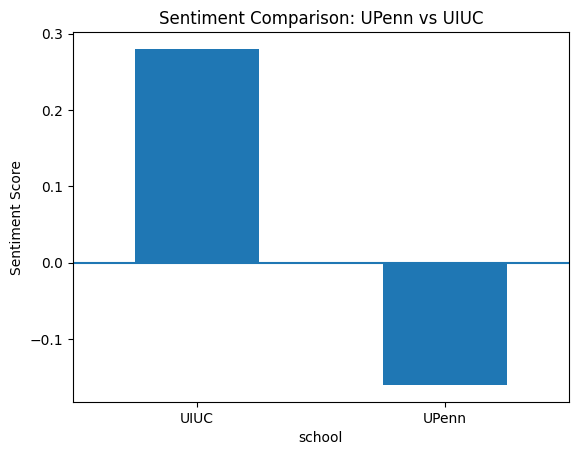

In [51]:
sentiment = sentiment_df.groupby("school")["manual_sentiment_score"].mean()

sentiment.plot(kind="bar")

plt.axhline(0) 
plt.title("Sentiment Comparison: UPenn vs UIUC")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=0)

plt.show()

Based on individual sentiment ratings, UIUC’s positive sentiment score was closely related to high scores in categories like community, school spirit, belonging, and overall happiness. UIUC’s value could be also derived from their overall stronger undergraduate experience. 


Penn’s sentiment analysis was much more complicated. Although the school scored well in individual post-grad and alumni-related categories, the current-student sentiment was much more negative, especially in categories of stress, competition, belonging, and mental health. It was interesting to note that Penn’s sentiment score tended to be much more positive after graduation rather than during enrollment, indicating that students reap benefits much later on. 

Based on both the quantitative and qualitative analysis of both schools, we came to the conclusion that Penn offers a stronger financial return, but appears to have a much weaker undergraduate experience based on stress and intensity. UIUC appears to offer a stronger undergraduate experience based on community and school spirit, but offers a lower long-term financial return. 

## The Business Schools: Wharton vs. Gies

To go deeper into our analysis between Penn and UIUC, we decided to compare Penn’s Wharton School and UIUC’s Gies College of Business. Both schools are nationally respected business institutions, yet they occupy very different places within the American higher education landscape. Wharton is hyper-selective, deeply connected to Wall Street, and synonymous with finance and executive leadership. Gies, meanwhile, embodies the strength of a flagship public university business school: accessible on a larger scale, highly specialized in accounting, and supported by an enormous alumni network concentrated throughout the Midwest and major corporate firms.


This distinction became central to many of the online responses defending or criticizing the chant. Critics argued that the statement ignored UIUC’s enormous professional credibility, particularly within the accounting. Supporters of Penn, meanwhile, pointed toward Wharton’s pipeline into investment banking and private equity and the disproportionate representation of Wharton alumni within Fortune 500 leadership positions. 


To begin evaluating this question, we first analyzed average starting salary data from the 2025 undergraduate career reports published by both schools.


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
from urllib.request import urlretrieve
from IPython.display import display, Markdown, HTML, Image

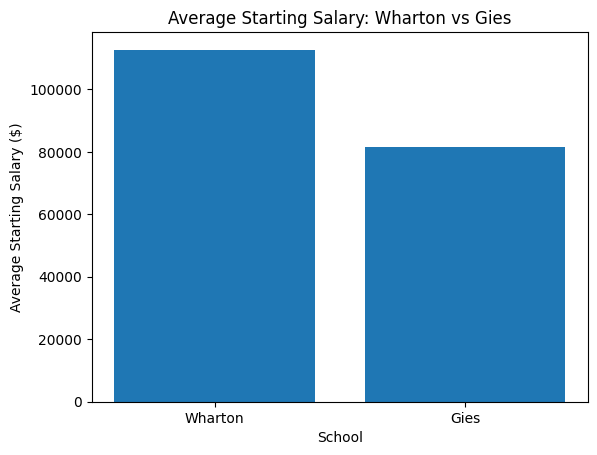

In [53]:
schools = ['Wharton', 'Gies']
salaries = [112684, 81621]

plt.figure()
plt.bar(schools, salaries)

plt.xlabel('School')
plt.ylabel('Average Starting Salary ($)')
plt.title('Average Starting Salary: Wharton vs Gies')

plt.show()

At first glance, the difference is striking. Graduates from Wharton School of the University of Pennsylvania reported an average starting salary of approximately $112,684, while graduates from Gies College of Business reported an average starting salary of $81,621: a gap of more than $31,000 immediately after graduation.


On the surface, these numbers appear to strongly validate Wharton’s reputation. The school has historically dominated placements into some of the highest-paying entry-level industries in the world, particularly investment banking, private equity, quantitative finance, and management consulting. Yet salary averages alone obscure important nuances.


We decided to expand the analysis further by examining salary outcomes across specific academic concentrations. Using manually extracted salary data from career reports published between 2021 and 2025, we constructed a longitudinal dataset comparing three overlapping fields where both schools demonstrate significant academic strength and student enrollment: accounting, finance, and marketing.


These majors were chosen deliberately because they reflect the distinct identities of each institution. Gies is nationally recognized for accounting and has built one of the strongest Big Four accounting pipelines in the country, particularly throughout Chicago. Wharton, by contrast, is overwhelmingly associated with finance, especially investment banking, private equity, and consulting placements.


The longitudinal data revealed several important trends.


In [55]:
wharton_majorsalary = pd.read_csv('../data/raw/Business_Schools/wharton_salaries.csv')
gies_majorsalary = pd.read_csv('../data/raw/Business_Schools/gies_salaries.csv')

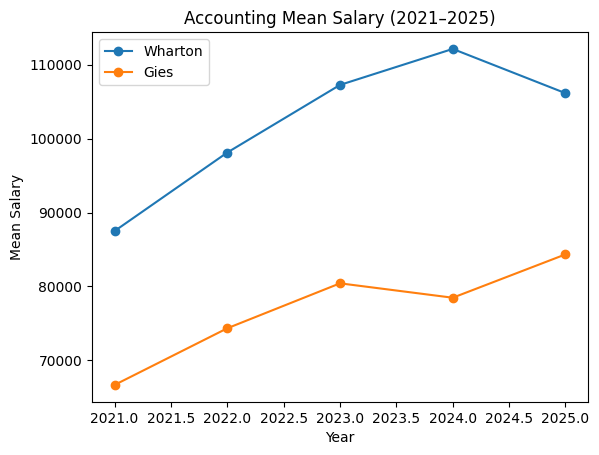

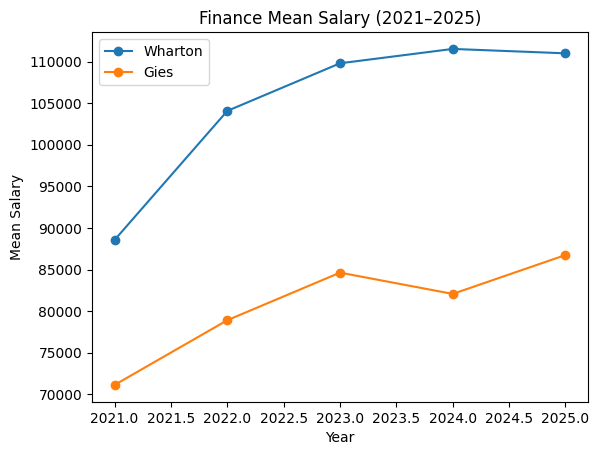

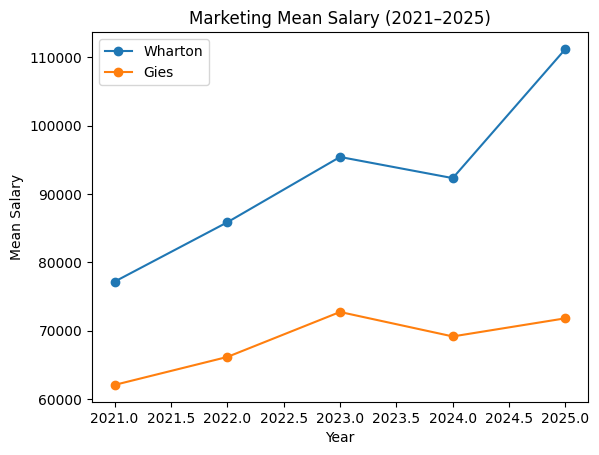

In [56]:
majors = ["Accounting", "Finance", "Marketing"]

for major in majors:
    w_data = wharton_majorsalary[wharton_majorsalary["major"] == major]
    g_data = gies_majorsalary[gies_majorsalary["major"] == major]

    plt.figure()
    plt.plot(w_data["year"], w_data["mean_salary"], marker='o', label="Wharton")
    plt.plot(g_data["year"], g_data["mean_salary"], marker='o', label="Gies")
    
    plt.title(f"{major} Mean Salary (2021–2025)")
    plt.xlabel("Year")
    plt.ylabel("Mean Salary")
    plt.legend()
    
    plt.show()

First, Wharton consistently maintained higher average starting salaries across all three concentrations. However, the gap between the schools varied substantially depending on the field. In accounting, while Wharton graduates still earned more on average, Gies salaries demonstrated a noticeably steeper upward trajectory over the four-year period. This trend likely reflects the increasing national prestige of Gies’ accounting program, which remains one of the most respected public accounting programs in the United States. As enrollment, recruiting activity, and institutional investment continue to grow, Gies accounting outcomes appear to be converging toward elite private-school compensation levels.

Finance presented a different pattern. Wharton salaries appeared to plateau around the low six-figure range, while Gies finance salaries increased more gradually but consistently over time. This plateau is unsurprising given the standardized compensation structures of elite finance industries. 

Additionally, marketing outcomes revealed another interesting trend. Salaries for both institutions rose steadily between 2021 and 2025, likely reflecting the increasing importance of digital advertising, analytics, and social media strategy within modern corporations. While Wharton maintained a higher overall salary average, the difference between schools was notably smaller than in finance.

However, interpreting Wharton’s salary data requires additional context. Unlike Gies students, Wharton undergraduates do not technically major in accounting, finance, or marketing in the traditional sense. All Wharton students graduate with a Bachelor of Science in Economics while pursuing concentrations within business disciplines. This distinction matters because Wharton students often enter industries unrelated to their academic concentration. A student concentrating in marketing may ultimately accept a six-figure consulting or investment banking offer, inflating salary averages associated with that concentration. In contrast, Gies students tend to enter careers more directly aligned with their declared major. A Gies accounting student is significantly more likely to work in accounting itself than a Wharton “accounting” concentrator.

This distinction ultimately reveals one of the biggest structural differences between the schools: Wharton functions less as a traditional business school and more as a gateway into elite professional industries broadly. The institution’s culture, alumni networks, and recruiting infrastructure heavily incentivize movement into finance and consulting regardless of academic concentration. In many ways, Wharton’s salary dominance reflects the strength of its recruiting ecosystem as much as the strength of individual academic departments.

## The Return on Investment of a Gies and Wharton Education

While salary outcomes are important, they only represent one side of the equation. Higher earnings do not automatically translate into stronger long-term value if they are accompanied by significantly higher educational costs. As a result, the next stage of our analysis focused on return on investment (ROI): how quickly graduates financially “break even” on the cost of attending each institution. To estimate ROI, we first calculated three separate cost categories for both schools: The estimated four-year sticker price, the average four-year cost paid by students overall, and the average four-year cost paid by federally aided students. These figures incorporated tuition, housing, financial aid distributions, and in-state versus out-of-state cost structures.


The second challenge involved modeling long-term salary progression. Because neither school publicly releases complete ten-year graduate salary trajectories, we instead used industry-based compensation progression models that reflected the dominant employment pipelines of each institution.


For Gies, this meant modeling compensation growth within Big Four accounting firms, where a substantial portion of graduates begin their careers. For Wharton, we modeled compensation growth within investment banking, the school’s most iconic and concentrated post-graduate pathway. Using publicly available compensation progression estimates from industry sources such as CaseBasix and Mergers & Inquisitions, we projected salary growth over a ten-year timeline and compared it against average educational cost.


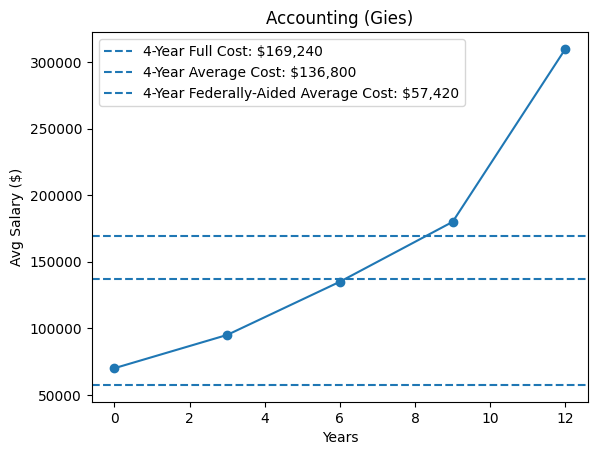

In [57]:
roi_comparison = pd.read_csv('../data/raw/Business_Schools/salary_progressions.csv')

gies_accounting = roi_comparison[roi_comparison['Industry'] == 'Accounting']
wharton_ib = roi_comparison[roi_comparison['Industry'] == 'Investment Banking']

plt.figure()
plt.plot(gies_accounting['Year'], gies_accounting['Avg_Salary'], 'o-')
plt.axhline(y=169240, linestyle='--', label='4-Year Full Cost: $169,240')
plt.axhline(y=136800, linestyle='--', label='4-Year Average Cost: $136,800')
plt.axhline(y=57420, linestyle='--', label='4-Year Federally-Aided Average Cost: $57,420')
plt.title('Accounting (Gies)')
plt.xlabel('Years')
plt.ylabel('Avg Salary ($)')
plt.legend()
plt.show()

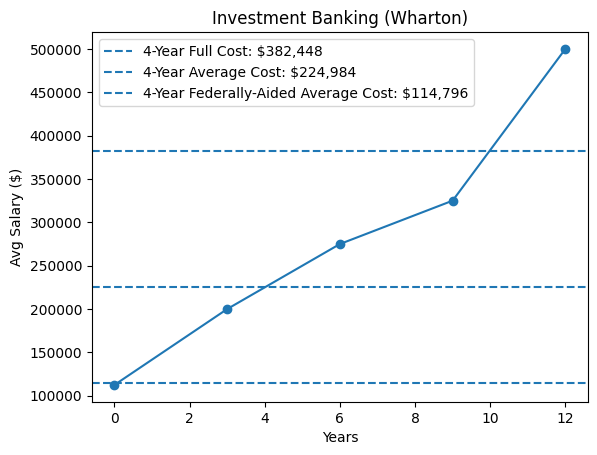

In [58]:
plt.figure()
plt.plot(wharton_ib['Year'], wharton_ib['Avg_Salary'], 'o-')
plt.axhline(y=382448, linestyle='--', label='4-Year Full Cost: $382,448')
plt.axhline(y=224984, linestyle='--', label='4-Year Average Cost: $224,984')
plt.axhline(y=114796, linestyle='--', label='4-Year Federally-Aided Average Cost: $114,796')
plt.title('Investment Banking (Wharton)')
plt.xlabel('Years')
plt.ylabel('Avg Salary ($)')
plt.legend()
plt.show()

Under these assumptions, Wharton graduates pursuing investment banking demonstrated the highest long-term earnings trajectory, with salaries rising from roughly $115k at graduation to approximately $500k by year twelve. Depending on which tuition benchmark is used, return on investment varied significantly: students paying the federally-aided average four-year cost ($114,796) could theoretically surpass educational costs almost immediately upon entering the workforce, while students paying the overall average cost ($224,984) or full four-year cost ($382,448) would generally reach positive ROI later, often between approximately four to ten years into their careers depending on compensation growth and bonuses. In contrast, Gies accounting graduates experienced slower but more stable salary growth, increasing from roughly $70,000 to $310,000 over twelve years. However, Gies students also faced substantially lower educational costs across all three tuition benchmarks, meaning that even with slower salary acceleration, many graduates could still achieve positive ROI relatively early in their careers with significantly lower financial risk and debt burden overall.

Importantly, this model has limitations. It assumes graduates remain in their original industries for extended periods of time and does not fully account for career pivots, geographic cost-of-living differences, or graduate school attendance. This limitation is particularly relevant for Wharton, where many graduates transition from investment banking into private equity, hedge funds, venture capital, or executive leadership roles after only several years: career shifts that can dramatically increase earnings beyond the scope of our model.

Nevertheless, the analysis highlights that Wharton’s extraordinary upfront costs are offset by unusually concentrated access to some of the highest-paying entry-level industries in the world. Gies, meanwhile, demonstrates a different form of value proposition: lower costs, broader accessibility, and strong placement into stable, high-demand professional sectors.

## Financial Aid and Socioeconomic Accessibility

Because the costs to attend above are general, we also wanted to look at costs based on family income. Using the US Department of Education's College Scorecards on UIUC and Penn, we found the cost of attendance for federally-aided students in different family income backgrounds. This data was also manually extracted from their website into an .csv file.

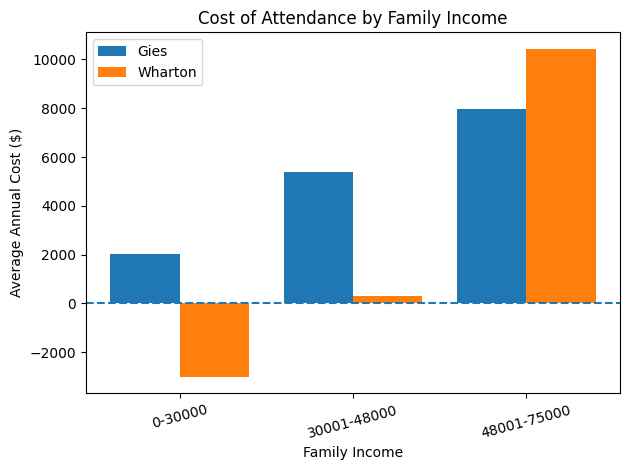

In [59]:
coa_business = pd.read_csv('../data/raw/Business_Schools/school_costs_by_income.csv').head(3)

family_income = list(range(len(coa_business['Family_Income'])))

plt.figure()
plt.bar([i - 0.2 for i in family_income], coa_business['Gies_Annual_Cost'], width=0.4, label='Gies')
plt.bar([i + 0.2 for i in family_income], coa_business['Wharton_Annual_Cost'], width=0.4, label='Wharton')
plt.xticks(family_income, coa_business['Family_Income'], rotation=15)
plt.xlabel('Family Income')
plt.ylabel('Average Annual Cost ($)')
plt.title('Cost of Attendance by Family Income')
plt.legend()
plt.tight_layout()
plt.axhline(y=0, linestyle='--')
plt.show()

For lower-income students receiving significant federal aid, Penn can actually become cheaper than UIUC. Highly aided Penn students often receive grants substantial enough to reduce tuition costs to near-zero levels, and in some cases, financial aid packages exceed direct educational expenses. In contrast, Gies demonstrated a more linear pricing structure where costs increased steadily alongside family income but rarely dropped into the deeply subsidized territory seen at Penn.


This finding complicates common assumptions about elite private education being universally inaccessible. For affluent families, Penn’s costs dramatically exceed UIUC’s. But for low-income, highly aided students, attending Wharton may actually produce both a faster ROI and lower long-term financial burden than attending Gies.


## Career Pipelines, School Culture, and Professional Identity

Beyond salary and cost, we also analyzed industry placement distributions to better understand the broader cultures and professional identities associated with each business school.

Using 2025 career outcome reports from both institutions, we categorized graduate placements into major industries including finance, consulting, accounting, technology, and miscellaneous sectors.

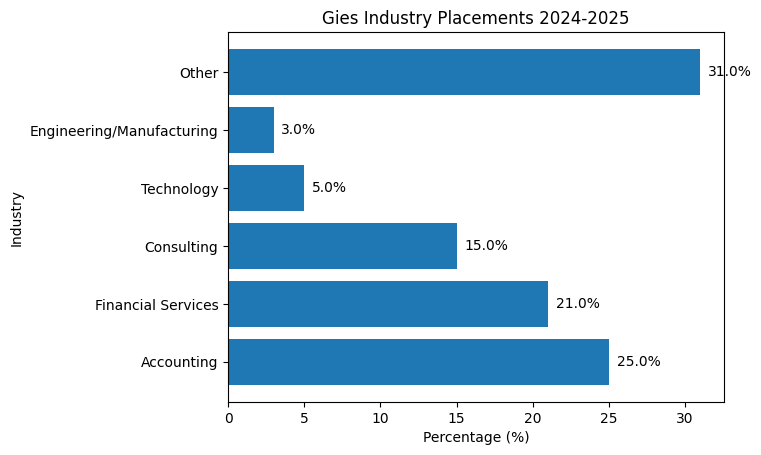

In [60]:
df = pd.read_csv('../data/raw/Business_Schools/IndustryPlacements.csv')

gies = df[df['Gies_Pct'] > 0]
wharton = df[df['Wharton_Pct'] > 0]

plt.figure()
plt.barh(gies['Industry'], gies['Gies_Pct'])

plt.xlabel('Percentage (%)')
plt.ylabel('Industry')
plt.title('Gies Industry Placements 2024-2025')

for i, v in enumerate(gies['Gies_Pct']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.show()

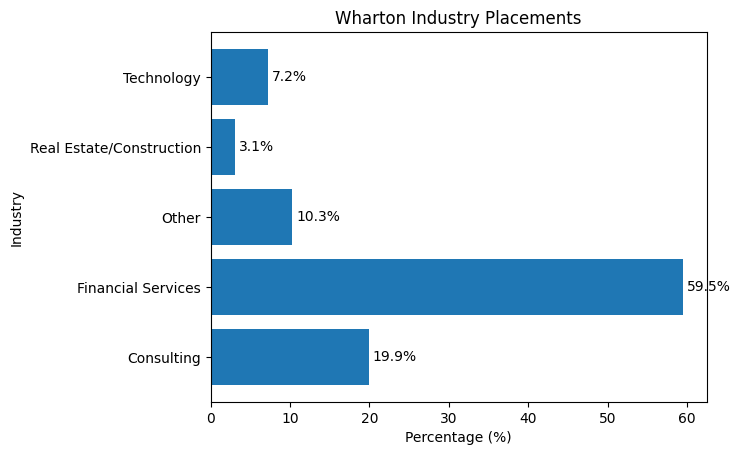

In [61]:
plt.figure()

wharton = df[df['Wharton_Pct'] > 0].copy()
wharton.loc[wharton['Wharton_Pct'] < 3, 'Industry'] = 'Other'
wharton = wharton.groupby('Industry')['Wharton_Pct'].sum().reset_index()

plt.barh(wharton['Industry'], wharton['Wharton_Pct'])

plt.xlabel('Percentage (%)')
plt.ylabel('Industry')
plt.title('Wharton Industry Placements')

for i, v in enumerate(wharton['Wharton_Pct']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.show()

Wharton displayed an extraordinarily concentrated placement pattern overwhelmingly centered around finance and consulting. So many graduates entered these industries that smaller sectors had to be aggregated into broader “other” categories for visualization purposes.


Gies College of Business, by contrast, demonstrated significantly greater industry diversification. Graduates dispersed across accounting, consulting, finance, technology, operations, marketing, and other business sectors in far more balanced proportions.


Interestingly, these placement distributions strongly mirrored online qualitative sentiment surrounding each institution.


Wharton is frequently described online as intensely pre-professional and highly competitive, with students often feeling pressure to pursue prestigious industries such as investment banking or consulting due to both campus culture and historical alumni precedent. The school’s recruiting infrastructure reinforces this cycle: because previous graduating classes concentrated heavily in finance and consulting, firms continue recruiting heavily at Penn, which in turn incentivizes future students to pursue the same industries.


The placement data visually reflects this dynamic. Wharton’s culture appears optimized toward maximizing access to elite, high-paying corporate careers.


Gies reflects a different institutional identity. Its placement diversity suggests a broader range of professional outcomes and a more flexible career culture. Rather than funneling students overwhelmingly into a narrow set of elite industries, Gies appears to support multiple pathways simultaneously, particularly in accounting, technology, and corporate business operations.


Ultimately, the comparison between Wharton and Gies reveals that the Penn Band chant oversimplified a far more complicated reality. Wharton undeniably possesses stronger elite-finance pipelines, higher average salaries, and more concentrated access to prestigious corporate networks. Yet Gies demonstrates remarkable strength in accessibility, accounting prestige, industry diversity, and long-term value relative to cost.


## How do Penn SEAS and UIUC Grainger Compare on Alumni Outcomes?

To complete our comparison between Penn and UIUC, we turned to engineering. Both schools house nationally respected programs, yet they occupy fundamentally different positions within that landscape. Penn SEAS is smaller and more selective, functioning less like a traditional engineering pipeline and more like a launchpad into finance, consulting, and technology. UIUC Grainger, ranked #5 in the country for undergraduate engineering, is one of the most technically rigorous programs in the United States and produces nearly four times as many engineers per graduating class.

For our engineering analysis, we used two dataframes:
penn_vs_uiuc_engineering_data_v3.csv for the structured comparison data
penn_vs_uiuc_engineering_raw_data_v3.md for context and interpretation

Our guiding questions:
1. How do starting salaries compare?
2. How have Penn SEAS salaries changed over time?
3. How do post-graduation outcomes differ?
4. What do the career pathways look like?
5. What does the ROI comparison suggest?


## Q1) How do starting salaries compare?

We started with the most recent salary comparison because that is the clearest high-level outcome measure.

Penn SEAS has a clear salary advantage in the most recent comparison.

The median comparison matters more than the average here. Penn reports a median of $122,500 while UIUC reports a median of $85,000, which is a gap of $37,500 per year immediately after graduation. UIUC's average ($96,766) is noticeably higher than its median, which signals a right-skewed distribution: a small number of very high earners in computer engineering and quantitative finance pull the mean upward significantly. For a typical graduate comparison, the median figures are the better benchmark.

It is also worth flagging a methodology note. Penn SEAS 2024 salary data came from only 98 respondents out of 467 graduates, coinciding with an unusually high average, likely reflecting selection bias toward high earners in quant and finance roles. UIUC Grainger's salary data comes from 318 of 1,971 graduates, a 16% response rate. Neither dataset is perfect, but both point in the same direction.

In [64]:
df = pd.read_csv('../data/raw/Engineering_Data/penn_vs_uiuc_engineering_data_v3.csv')

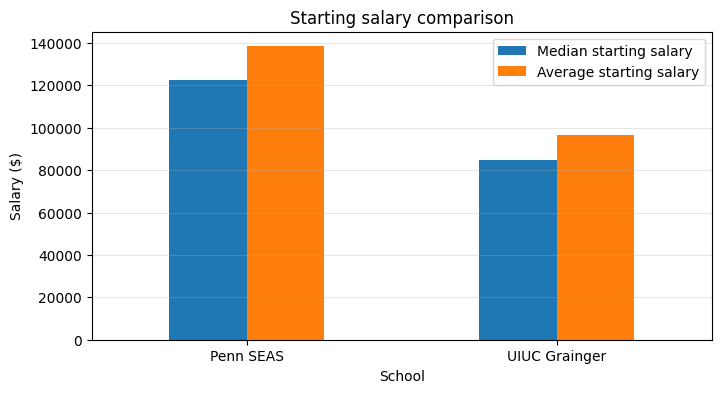

In [65]:
salary_compare = pd.DataFrame({
    "School": ["Penn SEAS", "UIUC Grainger"],
    "Median starting salary": [122500, 85000],
    "Average starting salary": [138360, 96766]
})

salary_compare.set_index("School").plot(kind="bar", figsize=(8,4))
plt.title("Starting salary comparison")
plt.ylabel("Salary ($)")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Penn SEAS has a clear salary advantage in the most recent comparison.

## Q2) How have Penn SEAS salaries changed over time?

Next, we looked at the Penn SEAS salary trend to see whether the most recent gap reflects a one-year anomaly or a broader pattern.

The salary advantage is not new. Penn SEAS average starting salaries rose from $87,571 for the Class of 2016 to $138,360 for the Class of 2024, nearly a 60% increase over eight years. The most notable jump came between 2021 and 2022, when technology, financial services, and consulting firms dramatically raised base salaries across the board. Penn SEAS flagged that year's figures as "unusually high,"  a market-driven spike that has since stabilized at a higher floor. The 2024 average is also worth treating with caution: a shift toward quant hedge funds and proprietary trading firms that year likely inflates the figure relative to underlying wage growth.

In [69]:
def money_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["—", "-", "nan", "None", ""]:
        return np.nan
    x = x.replace("$", "").replace(",", "").replace("~", "")
    m = re.search(r"-?\d+\.?\d*", x)
    return float(m.group()) if m else np.nan

def pct_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["—", "-", "nan", "None", ""]:
        return np.nan
    x = x.replace("%", "").replace("~", "")
    m = re.search(r"-?\d+\.?\d*", x)
    return float(m.group()) if m else np.nan

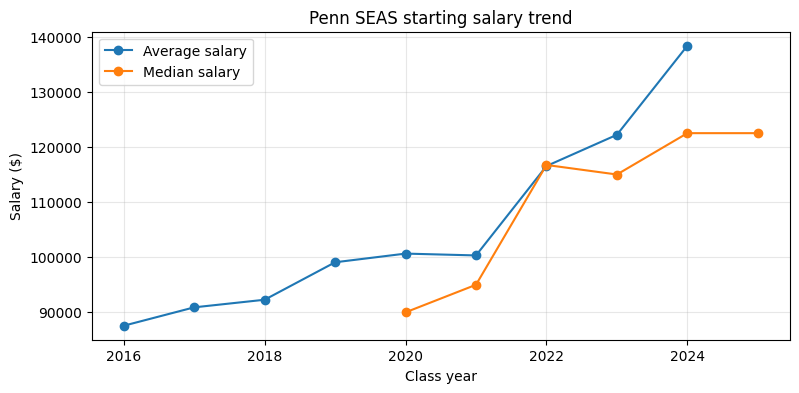

In [72]:
seas_trend = df[df["Category"] == "Salary - SEAS Trend"].copy()

avg_rows = seas_trend[seas_trend["Metric"].str.contains("Avg starting salary", case=False, na=False)].copy()
med_rows = seas_trend[seas_trend["Metric"].str.contains("Median starting salary", case=False, na=False)].copy()

avg_rows = avg_rows[avg_rows["Year/Cohort"].astype(str).str.fullmatch(r"\d{4}")]
med_rows = med_rows[med_rows["Year/Cohort"].astype(str).str.fullmatch(r"\d{4}")]

avg_rows["Year"] = avg_rows["Year/Cohort"].astype(int)
med_rows["Year"] = med_rows["Year/Cohort"].astype(int)

avg_rows["Penn Value"] = avg_rows["Penn SEAS"].apply(money_to_num)
med_rows["Penn Value"] = med_rows["Penn SEAS"].apply(money_to_num)

plt.figure(figsize=(9,4))
plt.plot(avg_rows["Year"], avg_rows["Penn Value"], marker="o", label="Average salary")
plt.plot(med_rows["Year"], med_rows["Penn Value"], marker="o", label="Median salary")
plt.title("Penn SEAS starting salary trend")
plt.xlabel("Class year")
plt.ylabel("Salary ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Q3) How do post-graduation outcomes differ?

Salary is only one piece of the story, so we next compared where graduates actually go after finishing school. The two schools have very different outcome structures.

Penn SEAS sends roughly 73-78% of its graduates directly into full-time employment, with around 19-23% continuing into graduate or professional school. UIUC Grainger shows nearly the opposite: only 52% enter full-time employment immediately, while 42% continue into graduate school, which is nearly double Penn's rate.

This is not a weakness for UIUC. It reflects a different educational philosophy. Grainger is a deeply technical school where graduate education is a natural and well-supported next step, with students regularly moving on to MIT, Stanford, Carnegie Mellon, and Berkeley. Penn's economic payoff shows up immediately. UIUC's is often delayed, more academically oriented, and in many cases followed by strong long-term earnings in research, academia, or senior technical roles.

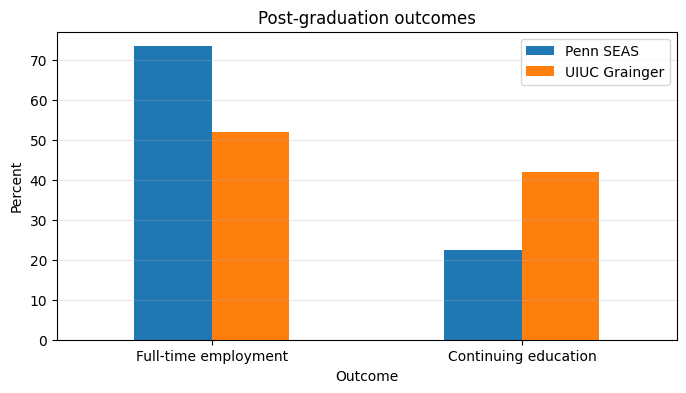

In [73]:
outcomes_compare = pd.DataFrame({
    "Outcome": ["Full-time employment", "Continuing education"],
    "Penn SEAS": [73.3, 22.3],
    "UIUC Grainger": [52.0, 42.0]
})

outcomes_compare.set_index("Outcome").plot(kind="bar", figsize=(8,4))
plt.title("Post-graduation outcomes")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Q4) What do the career pathways look like?

To understand why the salary gap exists, we looked at the kinds of industries each school feeds into.

This is the main structural difference between the two schools.

Penn SEAS functions as a hybrid pipeline. Technology is consistently the largest sector, accounting for 32-47% of employed graduates across recent years. Financial services is the second-largest and growing, reaching 26% in 2024, driven by a shift toward quantitative hedge funds and proprietary trading firms. Consulting accounts for another 10-17%. In practice, Penn SEAS engineers often end up at Goldman Sachs, McKinsey, Citadel, or Palantir before they end up at a traditional engineering firm.

UIUC Grainger sends graduates into a broader and more technically oriented set of industries. Its employer list reads like a who's who of American engineering: GE Aerospace, SpaceX, Tesla, Ford, Honeywell, Lockheed Martin, Siemens. The school's top earners skew toward computer engineering and software roles, but the broader Grainger population disperses across aerospace, civil, bioengineering, and manufacturing in ways that Penn SEAS simply does not.

Penn SEAS looks like a hybrid pipeline into tech, finance, and consulting. UIUC Grainger looks more like a traditional engineering and technical pipeline. That distinction helps explain why Penn graduates earn more immediately even though UIUC holds the significantly stronger pure engineering reputation, ranked #5 nationally versus Penn's #19.

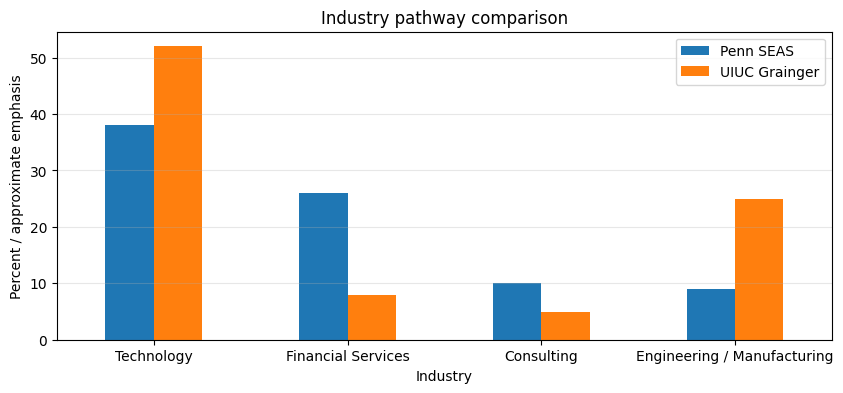

In [74]:
industry_compare = pd.DataFrame({
    "Industry": ["Technology", "Financial Services", "Consulting", "Engineering / Manufacturing"],
    "Penn SEAS": [38, 26, 10, 9],
    "UIUC Grainger": [52, 8, 5, 25]
})

industry_compare.set_index("Industry").plot(kind="bar", figsize=(10,4))
plt.title("Industry pathway comparison")
plt.ylabel("Percent / approximate emphasis")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Q5) What does the ROI comparison suggest?

Finally, we used the cost and salary comparison to think about how quickly the Penn premium pays for itself.

Median salary gap: $37,500 Estimated break-even period: 0.8 years

Penn's estimated four-year net cost for students receiving average financial aid is approximately $104,552. For UIUC in-state students receiving aid, that figure is roughly $74,260, a gap of about $30,000 over four years. Dividing that cost premium by the annual salary gap produces a break-even period of approximately 0.8 years. On these assumptions, the Penn premium pays for itself in less than a year of work.

There is also an important flip side for out-of-state students. UIUC out-of-state cost runs significantly higher, close enough to Penn's total that, for students who do not receive significant aid at either school, Penn can actually become the cheaper option while still delivering higher starting salaries. For those students, the ROI question essentially resolves itself.

This model has limitations. It assumes graduates remain in their first industries, does not account for cost-of-living differences between New York and the Midwest, and does not capture total compensation including signing bonuses. UIUC Grainger tracks signing bonuses separately, its median is $7,000 overall and $10,000 for computer engineers specifically, which partially narrows the first-year gap.

The two schools are not producing the same type of graduate at different salary levels. They are producing different types of graduates entirely. Penn SEAS is optimized for immediate entry into elite professional industries. UIUC Grainger is optimized for technical depth, graduate education, and the kind of engineering career that builds things rather than models them. Penn SEAS has the stronger short-term earnings outcome. UIUC Grainger has the stronger pure engineering reputation and sends a much larger share of students into graduate school, which delays immediate labor-market returns and makes direct salary comparisons imperfect.

The biggest difference is not prestige. It is a pathway structure.

## Conclusion: A Final Look at Penn, UIUC, and Institutional Value

Ultimately, our analysis revealed that the Penn Band chant was neither entirely accurate nor entirely baseless. Across nearly every quantitative metric, Penn demonstrated stronger short-term and long-term financial outcomes. Penn graduates earned substantially higher median salaries, achieved stronger ROI metrics, carried a lower debt-to-income burden despite similar debt levels, and benefited from highly concentrated pipelines into elite industries such as investment banking, consulting, and high-paying technology roles. 

This pattern remained visible in both Wharton and SEAS, where graduates leveraged hybrid pathways into finance, consulting, and technology that dramatically accelerated early-career earnings. In many ways, Penn’s advantage is in both academics and institutional positioning: the university functions as a gateway into some of the most economically powerful professional networks in the country.

At the same time, our data consistently complicated the idea that Penn’s outcomes exist solely because the institution is “better.” UIUC emerged as significantly stronger for broad-based economic mobility, enrolling students from less wealthy backgrounds while moving larger portions of its student population upward across income quintiles. UIUC students also reported substantially more positive undergraduate experiences, stronger senses of community and belonging, and lower levels of stress and hyper-competition. Even within engineering, where Penn graduates earned more immediately after graduation, UIUC Grainger demonstrated a fundamentally different educational model: one more deeply rooted in traditional engineering, technical specialization, and graduate education pathways rather than rapid entry into elite corporate industries.

In the end, the viral chant became symbolic of a broader national tension surrounding elite education in America. The statement “you’re gonna work for us someday” assumes that higher education can be reduced to hierarchy, prestige, and eventual economic dominance. Penn undeniably offers extraordinary financial leverage, particularly for students seeking access to elite professional pipelines. But UIUC demonstrates equal strength in areas often ignored in prestige-driven conversations: accessibility, upward mobility, community, flexibility, and overall student well-being. The question therefore is which outcome the broader internet or society chooses to value most. If success is defined by salary maximization and elite corporate placement, Penn holds a measurable advantage. If success is defined by broader mobility, institutional accessibility, technical specialization, and undergraduate quality of life, UIUC presents a compelling alternative model. Ultimately, what began as a controversial basketball chant ultimately exposed a deeper truth about higher education itself: prestige may shape opportunity, but it does not singularly define value.

## Creative Output

As part of our creative output, we decided to revise the original Penn band chant to be more accurate and reflective of our data findings. Here's what we created:

## ***“That’s alright, that’s okay, Median earnings lead the way. You’ve got spirit, we’ve got banks, Different schools, different ranks.”***

We chose this revised chant because it captures the core insight from our quantitative analysis while preserving the structure and tone of the original chant. The reference to “median earnings” directly reflects our finding that University of Pennsylvania graduates consistently outperform University of Illinois Urbana-Champaign in post-graduate salary outcomes and return on investment, particularly in high-paying industries like finance and consulting. At the same time, the contrast between “spirit” and “banks” intentionally mirrors the broader qualitative divide we observed: UIUC’s stronger sense of community, school spirit, and undergraduate satisfaction versus Penn’s more intense, pre-professional, and finance-driven culture.

Importantly, the chant is designed to reflect the asymmetry revealed in our data. The phrase “different schools, different ranks” acknowledges that the two institutions optimize for different definitions of success rather than existing in a simple hierarchy of “better” or “worse.” While Penn shows stronger financial outcomes and elite industry access, UIUC demonstrates broader accessibility and stronger student experience metrics. In this sense, the updated chant reframes the original provocation into a more data-aligned statement: one that recognizes measurable economic differences while still acknowledging that institutional value extends beyond earnings alone.


[Here is the original video for reference (Google Drive link to video)](https://drive.google.com/file/d/1xe98cLBqFDWA6T6IJZ6X2Ymr0LTaMI6A/view?usp=sharing)

[And here is our updated chant video (Google Drive link to video)](https://drive.google.com/file/d/1W8Rh0r5kzwxKzsjf9XjHw6HF_1qTlKLR/view?usp=sharing)